In [2]:
import kagglehub
import os
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, auc
)

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_file_path = os.path.join(path, "creditcard.csv")

In [3]:
df = pd.read_csv(csv_file_path)

# Separate features and target
X = df.drop(['Class'], axis=1)
y = df['Class']

# Stratified train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nData Split:")
print(f"  Training: {X_train.shape[0]:,} samples ({y_train.sum()} frauds, {y_train.mean()*100:.3f}%)")
print(f"  Test:     {X_test.shape[0]:,} samples ({y_test.sum()} frauds, {y_test.mean()*100:.3f}%)")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Train Decision Tree
print("\nTraining Decision Tree...")
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=100,
    min_samples_leaf=50,
    random_state=42
)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]



Data Split:
  Training: 227,845 samples (394 frauds, 0.173%)
  Test:     56,962 samples (98 frauds, 0.172%)

Training Decision Tree...


In [4]:
def plot_confusion_matrix(y_true, y_pred, title, filename):
    """Plot and save confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'],
                cbar_kws={'label': 'Count'})
    
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.ylabel('Actual', fontsize=12)
    plt.xlabel('Predicted', fontsize=12)
    
    # Add percentages
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            pct = cm[i, j] / total * 100
            plt.text(j+0.5, i+0.85, f'({pct:.2f}%)', 
                    ha='center', va='center', fontsize=9, color='red')
    
    plt.tight_layout()
    plt.savefig(f'results/{filename}', dpi=300, bbox_inches='tight')
    plt.close()
    
    return cm

def evaluate_model(y_true, y_pred, y_proba, model_name):
    """Comprehensive model evaluation"""
    print(f"\n{'='*70}")
    print(f"{model_name.upper()} EVALUATION")
    print(f"{'='*70}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\nConfusion Matrix:")
    print(f"  True Negatives  (TN): {tn:>6,}  (Normal correctly identified)")
    print(f"  False Positives (FP): {fp:>6,}  (Normal wrongly flagged as fraud)")
    print(f"  False Negatives (FN): {fn:>6,}  (Fraud MISSED!)")
    print(f"  True Positives  (TP): {tp:>6,}  (Fraud correctly caught)")
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    
    print(f"\nPerformance Metrics:")
    print(f"  Accuracy:  {accuracy*100:>6.2f}%  ← Misleading for imbalanced data!")
    print(f"  Precision: {precision*100:>6.2f}%  (Of fraud predictions, % correct)")
    print(f"  Recall:    {recall*100:>6.2f}%  (Of actual frauds, % caught)")
    print(f"  F1-Score:  {f1*100:>6.2f}%  (Harmonic mean of precision & recall)")
    print(f"  ROC-AUC:   {roc_auc:>6.4f}  (Ranking ability)")
    print(f"  PR-AUC:    {pr_auc:>6.4f}  (Better for imbalanced data)")
    
    # Calculate missed fraud percentage
    total_frauds = tp + fn
    missed_pct = (fn / total_frauds * 100) if total_frauds > 0 else 0
    print(f"\n  Missed {fn}/{total_frauds} frauds ({missed_pct:.1f}%)")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }

# Evaluate Logistic Regression
cm_lr = plot_confusion_matrix(y_test, y_pred_lr, 
                               'Confusion Matrix - Logistic Regression',
                               'phase2_cm_logistic_regression.png')
metrics_lr = evaluate_model(y_test, y_pred_lr, y_proba_lr, 
                            'Logistic Regression')

# Evaluate Decision Tree
cm_dt = plot_confusion_matrix(y_test, y_pred_dt,
                               'Confusion Matrix - Decision Tree',
                               'phase2_cm_decision_tree.png')
metrics_dt = evaluate_model(y_test, y_pred_dt, y_proba_dt,
                            'Decision Tree')



LOGISTIC REGRESSION EVALUATION

Confusion Matrix:
  True Negatives  (TN): 56,851  (Normal correctly identified)
  False Positives (FP):     13  (Normal wrongly flagged as fraud)
  False Negatives (FN):     36  (Fraud MISSED!)
  True Positives  (TP):     62  (Fraud correctly caught)

Performance Metrics:
  Accuracy:   99.91%  ← Misleading for imbalanced data!
  Precision:  82.67%  (Of fraud predictions, % correct)
  Recall:     63.27%  (Of actual frauds, % caught)
  F1-Score:   71.68%  (Harmonic mean of precision & recall)
  ROC-AUC:   0.9605  (Ranking ability)
  PR-AUC:    0.7414  (Better for imbalanced data)

  Missed 36/98 frauds (36.7%)

DECISION TREE EVALUATION

Confusion Matrix:
  True Negatives  (TN): 56,832  (Normal correctly identified)
  False Positives (FP):     32  (Normal wrongly flagged as fraud)
  False Negatives (FN):     26  (Fraud MISSED!)
  True Positives  (TP):     72  (Fraud correctly caught)

Performance Metrics:
  Accuracy:   99.90%  ← Misleading for imbalanced d


MODEL COMPARISON
   Metric Logistic Regression Decision Tree
 Accuracy              99.91%        99.90%
Precision              82.67%        69.23%
   Recall              63.27%        73.47%
 F1-Score              71.68%        71.29%
  ROC-AUC              0.9605        0.9417
   PR-AUC              0.7414        0.7633


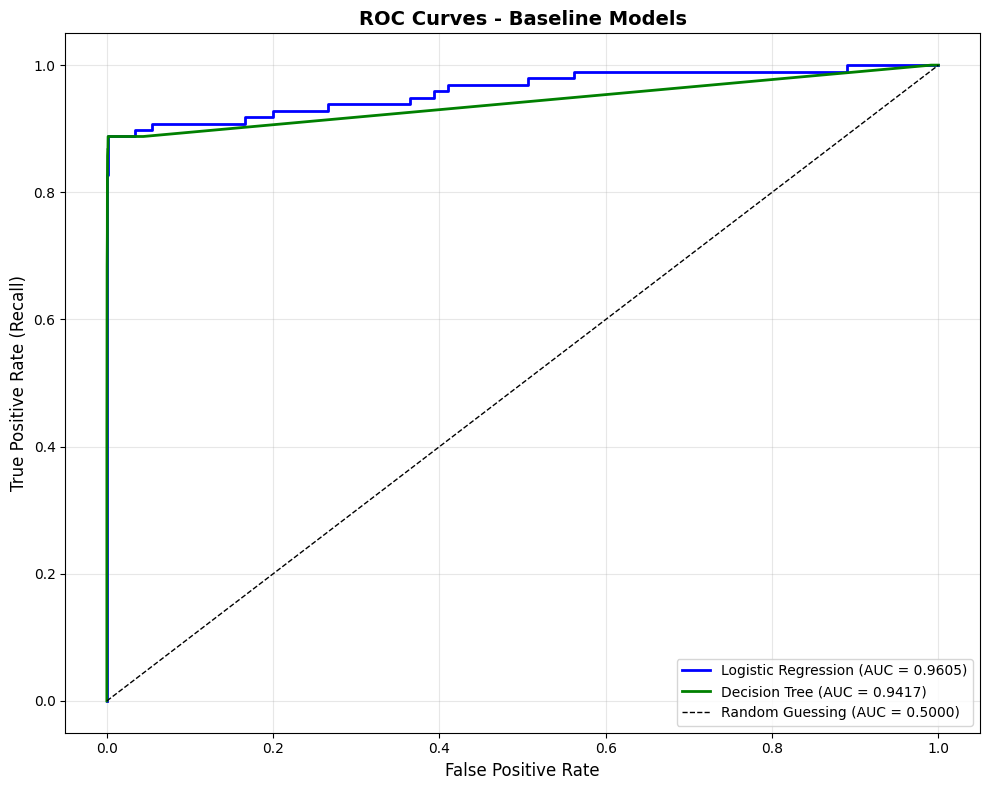

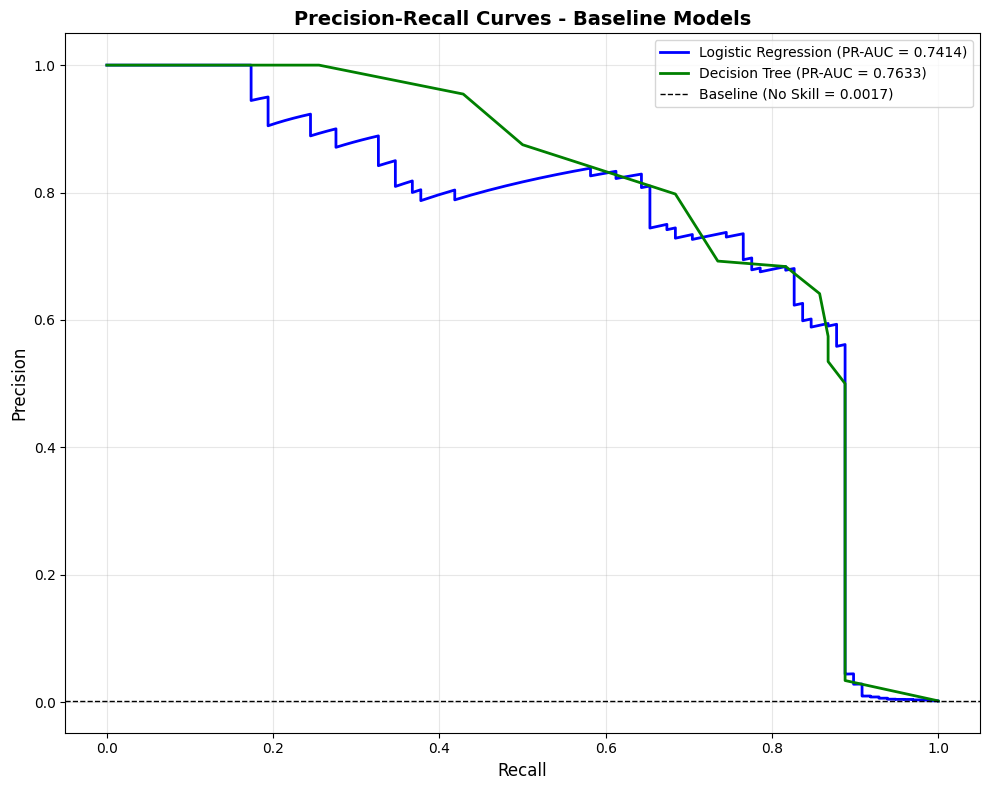

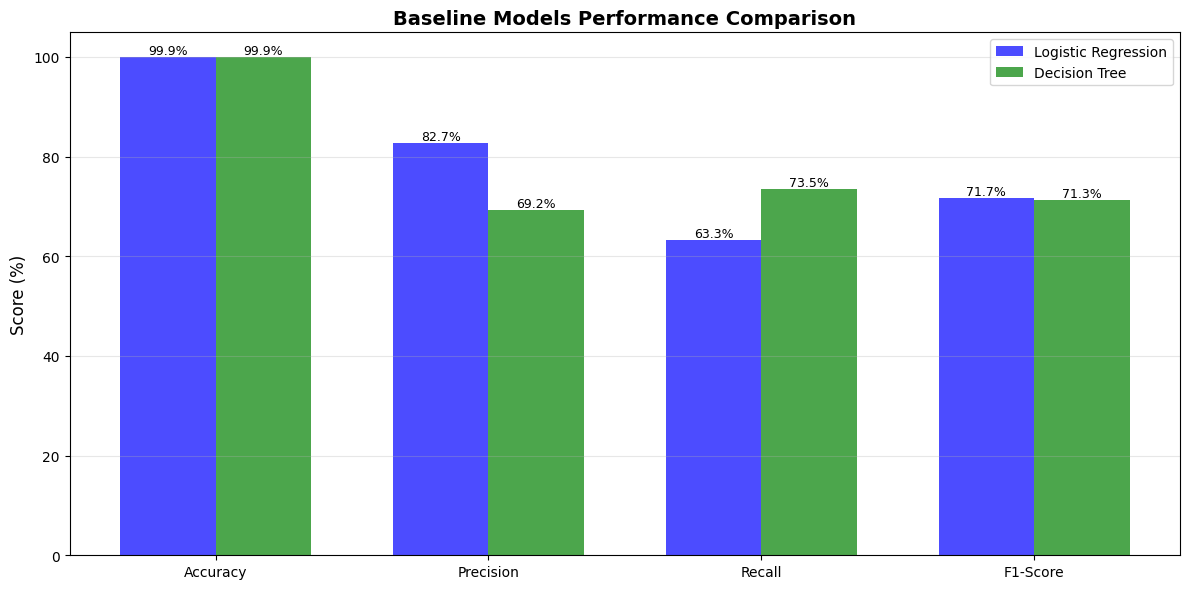

In [7]:
# DEMONSTRATE FAILURE OF ACCURACY

# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC'],
    'Logistic Regression': [
        f"{metrics_lr['accuracy']*100:.2f}%",
        f"{metrics_lr['precision']*100:.2f}%",
        f"{metrics_lr['recall']*100:.2f}%",
        f"{metrics_lr['f1']*100:.2f}%",
        f"{metrics_lr['roc_auc']:.4f}",
        f"{metrics_lr['pr_auc']:.4f}"
    ],
    'Decision Tree': [
        f"{metrics_dt['accuracy']*100:.2f}%",
        f"{metrics_dt['precision']*100:.2f}%",
        f"{metrics_dt['recall']*100:.2f}%",
        f"{metrics_dt['f1']*100:.2f}%",
        f"{metrics_dt['roc_auc']:.4f}",
        f"{metrics_dt['pr_auc']:.4f}"
    ]
})

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))

# Plot ROC curves
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)

ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {metrics_lr["roc_auc"]:.4f})', 
        linewidth=2, color='blue')
ax.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {metrics_dt["roc_auc"]:.4f})', 
        linewidth=2, color='green')
ax.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.5000)', linewidth=1)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves - Baseline Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

# Plot Precision-Recall curves
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_proba_lr)
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_proba_dt)

baseline_precision = y_test.sum() / len(y_test)

ax.plot(recall_lr, precision_lr, 
        label=f'Logistic Regression (PR-AUC = {metrics_lr["pr_auc"]:.4f})', 
        linewidth=2, color='blue')
ax.plot(recall_dt, precision_dt, 
        label=f'Decision Tree (PR-AUC = {metrics_dt["pr_auc"]:.4f})', 
        linewidth=2, color='green')
ax.axhline(y=baseline_precision, color='k', linestyle='--', 
           label=f'Baseline (No Skill = {baseline_precision:.4f})', linewidth=1)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - Baseline Models', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show() 
plt.close()

# Create bar chart comparison
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_values = [metrics_lr['accuracy']*100, metrics_lr['precision']*100, 
             metrics_lr['recall']*100, metrics_lr['f1']*100]
dt_values = [metrics_dt['accuracy']*100, metrics_dt['precision']*100,
             metrics_dt['recall']*100, metrics_dt['f1']*100]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax.bar(x - width/2, lr_values, width, label='Logistic Regression', 
               color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, dt_values, width, label='Decision Tree', 
               color='green', alpha=0.7)

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Baseline Models Performance Comparison', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
plt.close()